In [ ]:
#sam2 install
!pip install -q git+https://github.com/facebookresearch/sam2.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 7.1 MB/s eta 0:00:00


In [ ]:
# install dependencies
!pip install -q transformers torch pillow matplotlib opencv-python


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Import necessary libraries
import torch
import cv2
import matplotlib.pyplot as plt
image = cv2.imread("Screenshot 2026-06-04 213334.png")

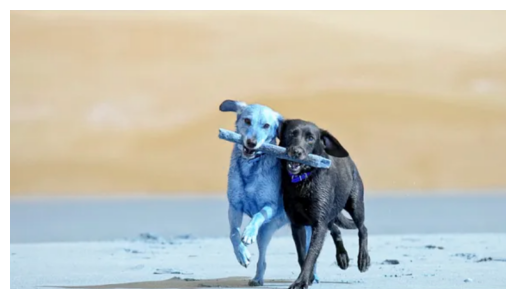

In [ ]:
# Display the uploaded image
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
# Load the SAM model
from transformers import pipeline
segmenter = pipeline(
    "mask-generation",
    model="facebook/sam-vit-base"
)

image = cv2.imread("Screenshot 2026-06-04 213334.png")

result = segmenter(image)

print("Masks Generated:", len(result["masks"]))
result = segmenter(image)
print(result.keys())

Loading weights: 100%
 314/314 [00:00<00:00, 648.55it/s, Materializing param=vision_encoder.pos_embed]
Masks Generated: 15
dict_keys(['masks', 'scores'])

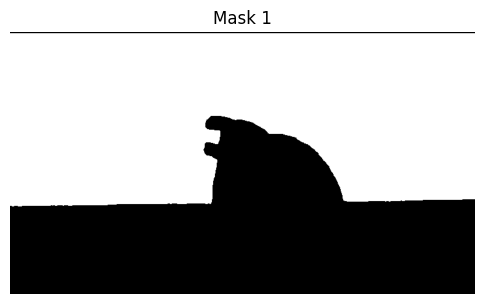

In [ ]:
# Display mask 1 
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(result["masks"][0], cmap="gray")
plt.title("Mask 1")
plt.axis("off")
plt.show()

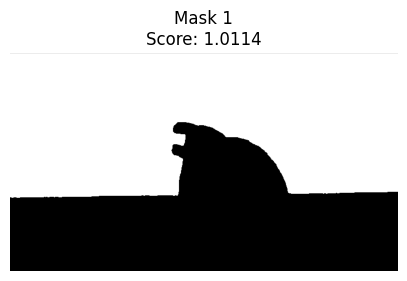

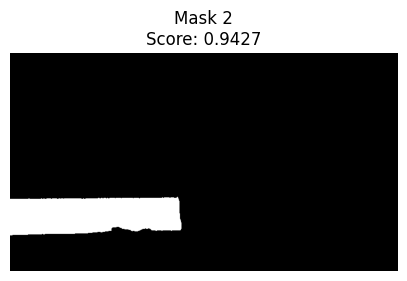

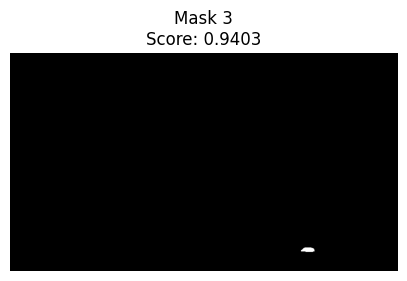

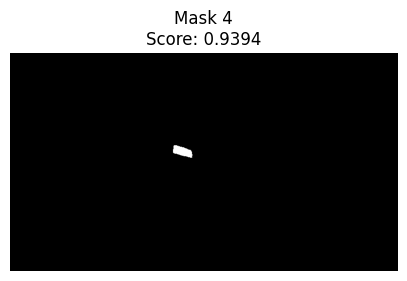

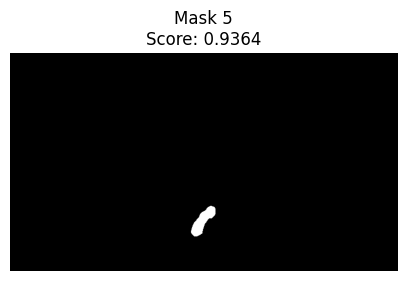

In [ ]:
# Display 5 masks with their confidence scores
for i in range(5):

    plt.figure(figsize=(5,5))
    plt.imshow(result["masks"][i], cmap="gray")

    plt.title(
        f"Mask {i+1}\nScore: {result['scores'][i]:.4f}"
    )

    plt.axis("off")
    plt.show()

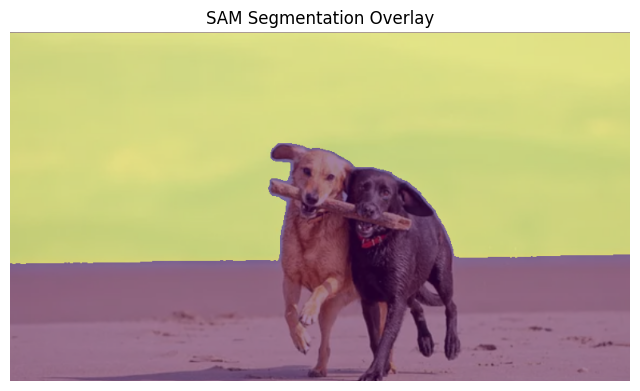

In [ ]:
# Display segmentation overlay
import numpy as np

mask = np.array(result["masks"][0])

plt.figure(figsize=(8,8))

plt.imshow(image)
plt.imshow(mask, alpha=0.5)

plt.title("SAM Segmentation Overlay")
plt.axis("off")

plt.show()

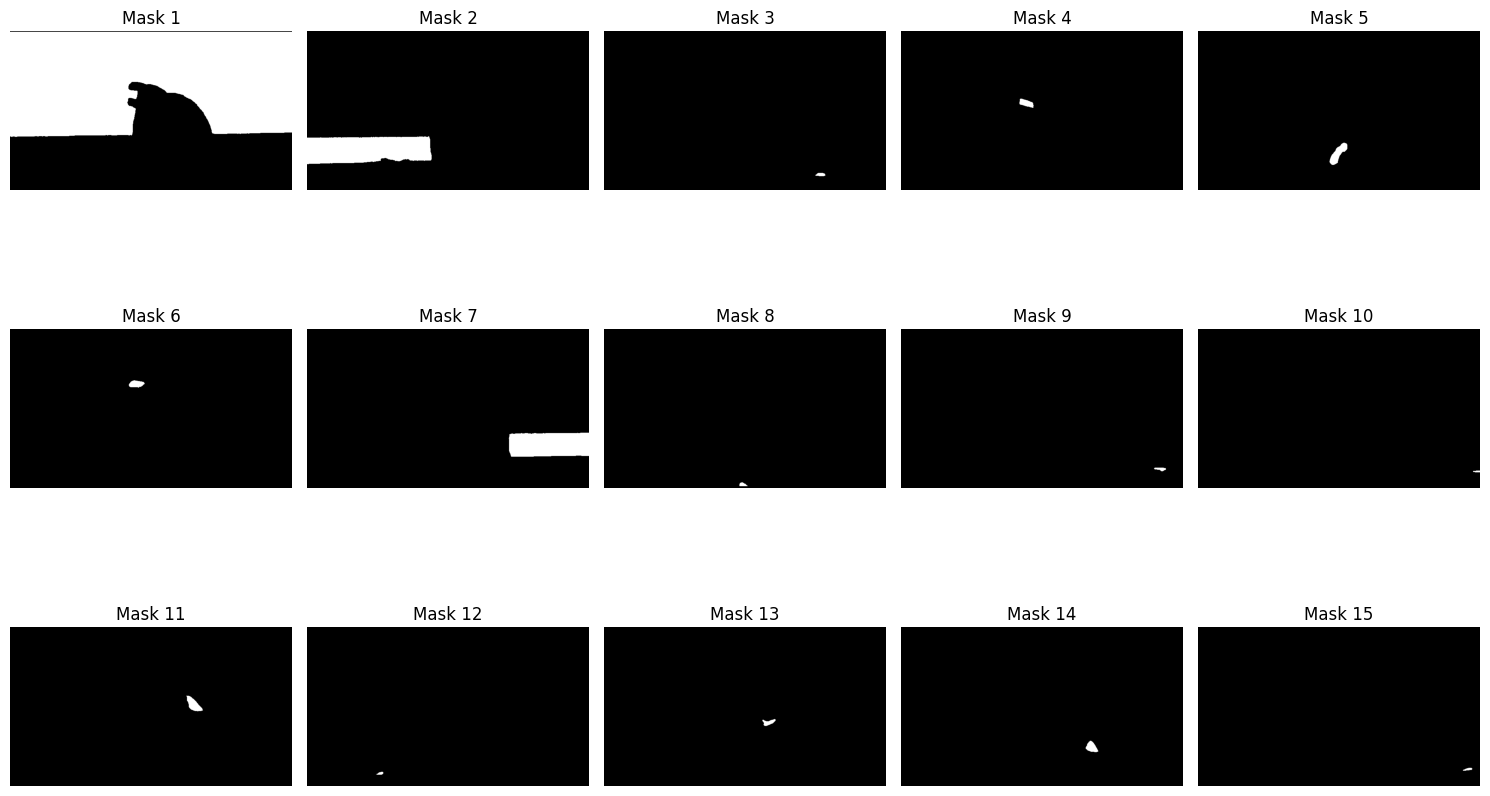

In [ ]:
# Display all masks in a grid
fig, axes = plt.subplots(
    3,
    5,
    figsize=(15,10)
)

for i, ax in enumerate(axes.flatten()):

    ax.imshow(
        result["masks"][i],
        cmap="gray"
    )

    ax.set_title(
        f"Mask {i+1}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()